In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
import os
os.chdir("D:/Violence_detection")
print(os.getcwd())

D:\Violence_detection


In [7]:
model = load_model("violence_model_TL.h5")

In [8]:
processed_path = r"processed_data"

In [9]:
violence_path = os.path.join(processed_path, "V")
nonviolence_path = os.path.join(processed_path, "NV")

In [10]:
from collections import defaultdict
video_frames = defaultdict(list)

# Violence frames
for frame in os.listdir(violence_path):
    parts = frame.split("_")
    video_id = f"V_{parts[1]}"
    video_frames[video_id].append(os.path.join(violence_path, frame))

# NonViolence frames
for frame in os.listdir(nonviolence_path):
    parts = frame.split("_")
    video_id = f"NV_{parts[1]}"
    video_frames[video_id].append(os.path.join(nonviolence_path, frame))

# Sort frames for LSTM
for vid in video_frames:
    video_frames[vid].sort()

print("Total videos:", len(video_frames))

Total videos: 2350


In [11]:
video_ids = list(video_frames.keys())

print("Example video IDs:", video_ids[:10])
print("Total videos:", len(video_ids))

Example video IDs: ['V_1000', 'V_1001', 'V_1002', 'V_1003', 'V_1004', 'V_1005', 'V_1006', 'V_1007', 'V_1008', 'V_1009']
Total videos: 2350


In [12]:
labels = []

for vid in video_ids:
    if vid.startswith("V"):
        labels.append(1)
    else:
        labels.append(0)

print(labels[:20])
print(labels[-20:])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
from sklearn.model_selection import train_test_split

train_ids, test_ids, train_labels, test_labels = train_test_split(
    video_ids,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train videos:", len(train_ids))
print("Test videos:", len(test_ids))

Train videos: 1880
Test videos: 470


In [14]:
import cv2
import numpy as np
import tensorflow as tf

class VideoGenerator(tf.keras.utils.Sequence):

    def __init__(self, video_ids, labels, video_frames, batch_size=4):
        self.video_ids = video_ids
        self.labels = labels
        self.video_frames = video_frames
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.video_ids) / self.batch_size))

    def __getitem__(self, idx):

        batch_ids = self.video_ids[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X = []
        y = []

        for vid, label in zip(batch_ids, batch_labels):

            frames = sorted(self.video_frames[vid])

            sequence = []

            for frame in frames:
                img = cv2.imread(frame)
                img = cv2.resize(img,(160,160))
                img = img / 255.0
                sequence.append(img)

            X.append(sequence)
            y.append(label)

        return np.array(X), np.array(y)

In [15]:
train_gen = VideoGenerator(train_ids, train_labels, video_frames, batch_size=4)
test_gen = VideoGenerator(test_ids, test_labels, video_frames, batch_size=4)

In [16]:
X, y = train_gen[0]
print(X.shape, y.shape)

(4, 16, 160, 160, 3) (4,)


In [18]:
loss, acc = model.evaluate(test_gen)

print("Test Accuracy:", acc)

118/118 [==============================] - 115s 890ms/step - loss: 0.1907 - accuracy: 0.9170
Test Accuracy: 0.9170212745666504


In [19]:
loss, train_acc = model.evaluate(train_gen)

print("Train Accuracy:", train_acc)

470/470 [==============================] - 370s 789ms/step - loss: 0.0443 - accuracy: 0.9846
Train Accuracy: 0.9845744967460632


In [20]:
y_true = []
y_pred = []

for i in range(len(test_gen)):
    X_batch, y_batch = test_gen[i]
    preds = model.predict(X_batch, verbose=0)

    y_true.extend(y_batch)
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [21]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[203  21]
 [ 18 228]]


In [22]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       224
           1       0.92      0.93      0.92       246

    accuracy                           0.92       470
   macro avg       0.92      0.92      0.92       470
weighted avg       0.92      0.92      0.92       470



In [23]:
print("Test Accuracy:", accuracy_score(y_true, y_pred))

Test Accuracy: 0.9170212765957447


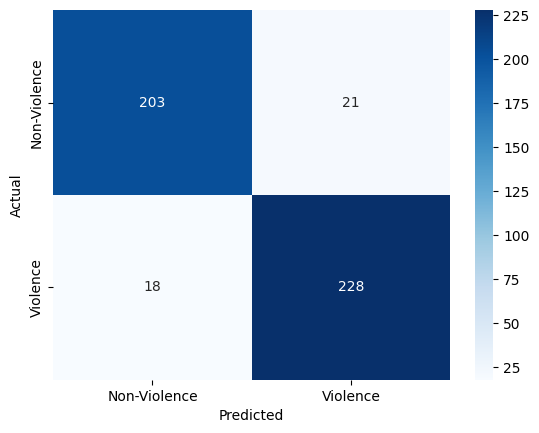

In [24]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Violence","Violence"],
            yticklabels=["Non-Violence","Violence"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()